## 1. Load and Inspect the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

all_files = glob.glob(os.path.join('./MachineLearningCVE/' , "*.csv"))

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
df.columns = df.columns.str.strip()

print(f"Dataset Loaded. Shape: {df.shape}")
print("\nList of features: ")
print(df.columns)
print("\nValue counts for all attack types:")
print(df['Label'].value_counts())

def dynamic_grouping(label):
    l = str(label).lower()

    if 'benign' in l:
        return 'Benign'
    elif 'ddos' in l:
        return 'DDoS'
    elif 'dos' in l or 'heartbleed' in l:
        return 'DoS'
    elif 'web attack' in l or 'sql injection' in l or 'xss' in l:
        return 'Web Attack'
    elif 'patator' in l:
        return 'Brute Force'
    elif 'bot' in l:
        return 'Botnet'
    elif 'portscan' in l:
        return 'PortScan'
    elif 'infiltration' in l:
        return 'Infiltration'
    else:
        return 'Other'


df['Attack Family'] = df['Label'].apply(dynamic_grouping)

Dataset Loaded. Shape: (2830743, 79)

List of features: 
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packe


Mapping logic:
Attack Family                Benign  Botnet  Brute Force    DDoS     DoS  \
Label                                                                      
BENIGN                      2273097       0            0       0       0   
Bot                               0    1966            0       0       0   
DDoS                              0       0            0  128027       0   
DoS GoldenEye                     0       0            0       0   10293   
DoS Hulk                          0       0            0       0  231073   
DoS Slowhttptest                  0       0            0       0    5499   
DoS slowloris                     0       0            0       0    5796   
FTP-Patator                       0       0         7938       0       0   
Heartbleed                        0       0            0       0      11   
Infiltration                      0       0            0       0       0   
PortScan                          0       0            0       0       0

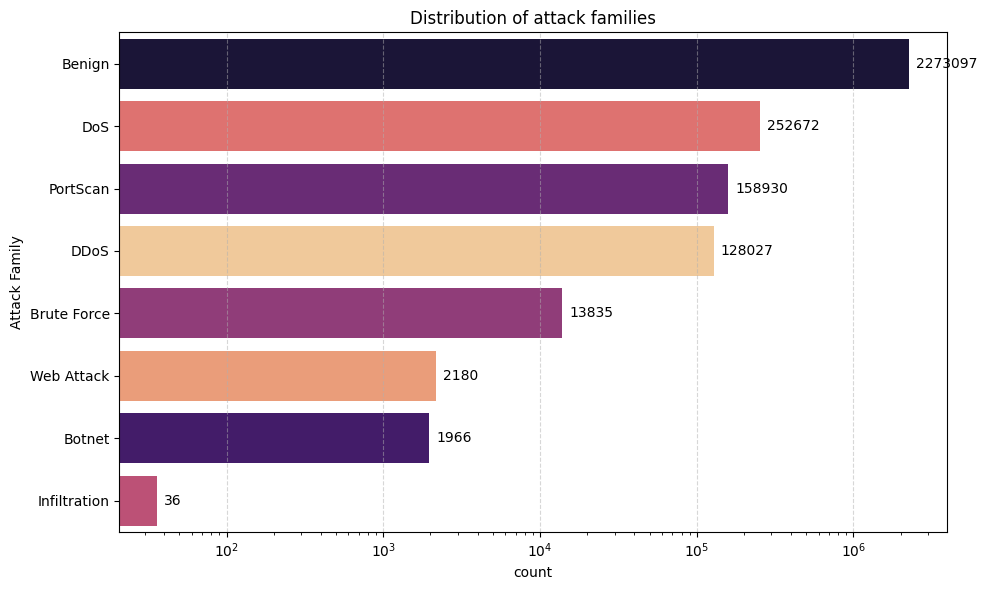


Sample rows:
         Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean   Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean   Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Average Packet Size  Avg Fwd Segment Size  Avg Bwd Segment S

In [2]:
mapping_check = pd.crosstab(df['Label'], df['Attack Family'])
print("\nMapping logic:")
print(mapping_check.loc[:, (mapping_check != 0).any(axis=0)])

print("\nAttack Family target distribution:")
print(df['Attack Family'].value_counts())

print("\nSummary of the dataset:")
print(df.describe().to_string())

plt.figure(figsize=(10, 6))
order = df['Attack Family'].value_counts().index
ax = sns.countplot(y='Attack Family', data=df, order=order, palette='magma', hue='Attack Family', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha = 'left', va = 'center', xytext = (5, 0),
                textcoords = 'offset points')

plt.title('Distribution of attack families')
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nSample rows:")
print(df.sample(5).to_string())

## 2. Exploratory Data Analysis (EDA)

Total NaN values: 1358
Total infinite values: 4376

Summary statistics:
       Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean   Fwd IAT Std   Fwd IAT Max   Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean   Bwd IAT Std   Bwd IAT Max   Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  

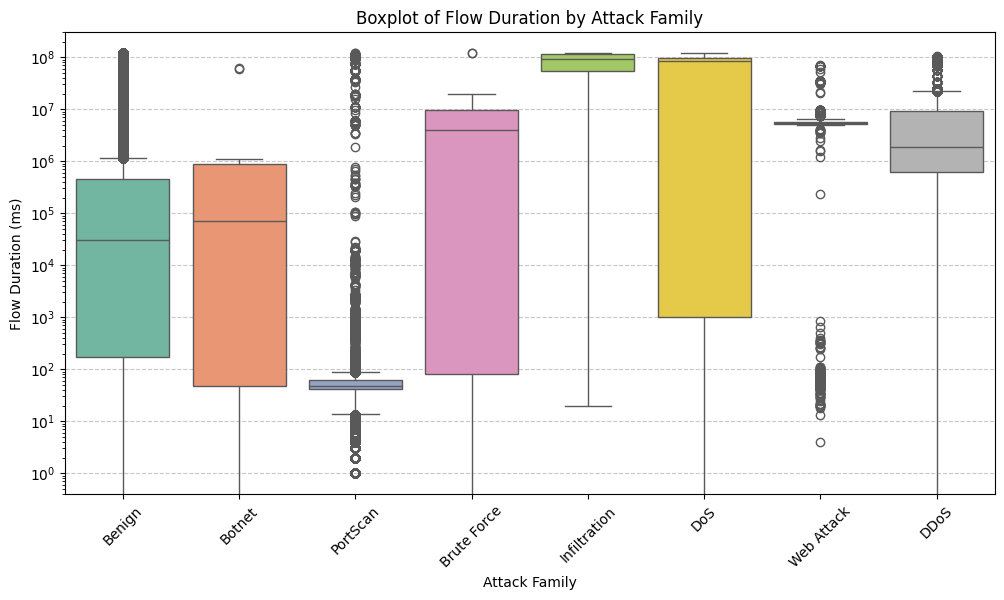

In [4]:
import numpy as np

missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()

numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
total_inf = inf_counts.sum()

print(f"Total NaN values: {total_missing}")
print(f"Total infinite values: {total_inf}")

print("\nSummary statistics:")
stats_df = df.replace([np.inf, -np.inf], np.nan)
print(stats_df.describe().to_string())

print("\nOutlier detection:")
target_col = 'Flow Duration'
clean_col = stats_df[target_col].dropna()

Q1 = clean_col.quantile(0.25)
Q3 = clean_col.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = clean_col[(clean_col < lower_bound) | (clean_col > upper_bound)]

print(f"Feature evaluated: '{target_col}'")
print(f"- Q1 (25%): {Q1:,.2f}")
print(f"- Q3 (75%): {Q3:,.2f}")
print(f"- IQR:      {IQR:,.2f}")
print(f"- Outlier thresholds: < {lower_bound:,.2f} or > {upper_bound:,.2f}")
print(f"- Total outliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

plt.figure(figsize=(12, 6))
plot_sample = stats_df

sns.boxplot(x='Attack Family', y='Flow Duration', data=plot_sample, palette='Set2', hue='Attack Family', legend=False)

plt.yscale('log')
plt.title('Boxplot of Flow Duration by Attack Family')
plt.ylabel('Flow Duration (ms)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:**
1. PortScan is fast, which confirms that port scanning involves sending many short, rapid packets to check open ports.
2. Infiltration and DoS have the highest medians, which is consistent with their nature. Infiltration maintains a persistent connection, and DoS attempts to tie up server resources for as long as possible.
3. Benign traffic has a large spread and many outliers extending upwards. This indicates that normal user traffic varies wildly, making it difficult to distinguish from attacks based on duration alone.
4. The Web Attack box is quite compressed compared to others. This suggests these attacks follow a programmed, consistent timing pattern.

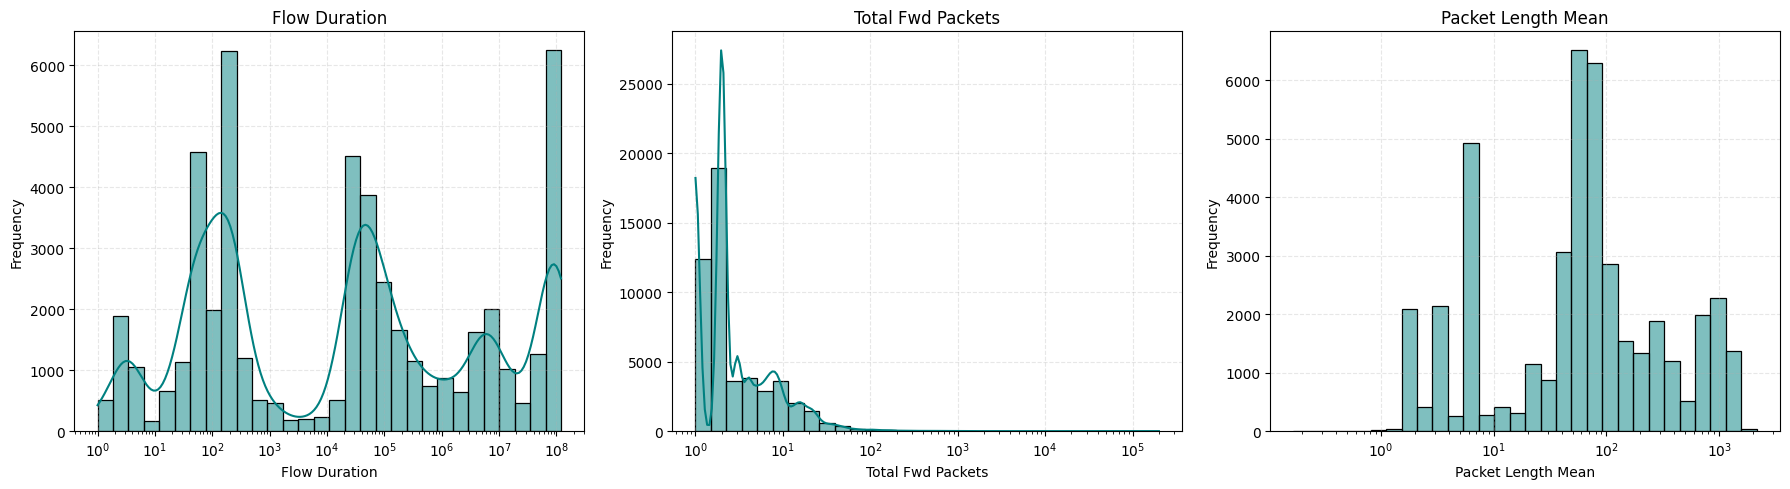

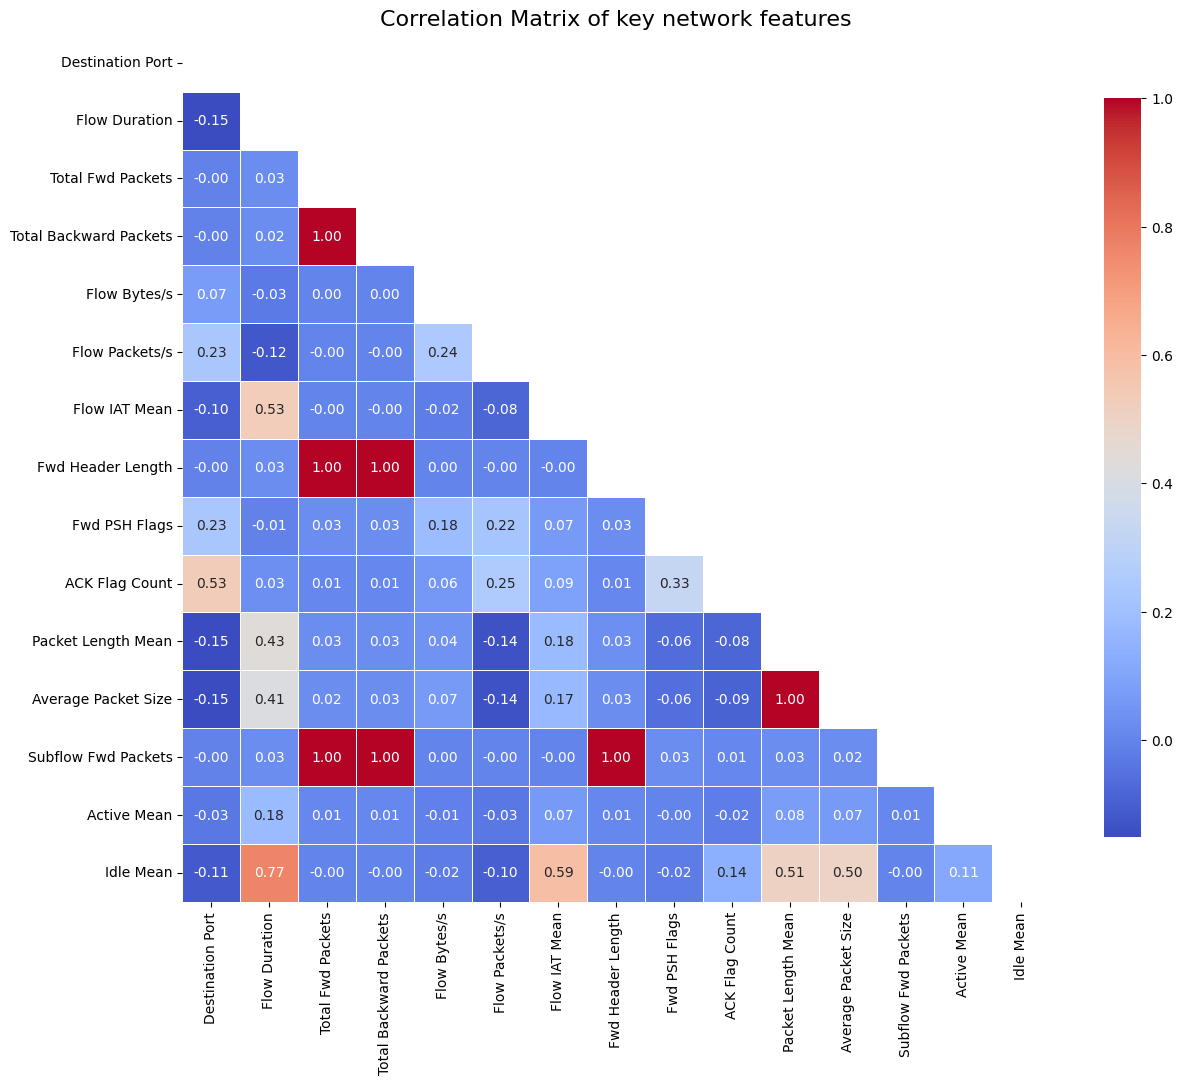

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
df_sample, _ = train_test_split(df_clean, train_size=50000,
                                stratify=df_clean['Attack Family'],
                                random_state=42)

key_features = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean']

plt.figure(figsize=(18, 5))

for i, feature in enumerate(key_features):
    plt.subplot(1, 3, i+1)

    sns.histplot(df_sample[feature], kde=True, bins=30, log_scale=True, color='teal')

    plt.title(f'{feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

cols_to_corr = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Fwd Header Length', 'Fwd PSH Flags',
    'ACK Flag Count', 'Packet Length Mean', 'Average Packet Size',
    'Subflow Fwd Packets', 'Active Mean', 'Idle Mean'
]

corr_matrix = df_sample[cols_to_corr].corr()

plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of key network features', fontsize=16)
plt.show()

**Interpretation:**
1. Flow Duration: It shows distinct groups, like short bursts, longer connections and maximum timeouts.
2. Total Fwd Packets: This is a classic right-skewed distribution. The vast majority of flows consist of very few packets and the curve flattens but extends far to the right.
3. Packet Length Mean: The graph is jagged because network packet sizes are standardized. There are small peaks which likely represent control packets and large peaks which are packets hitting the MTU. There are few packets in between.
4. Correlation matrix: There are several features with a correlation of 1.00, meaning they contain identical information. Volume Cluster: *Total Fwd Packets*, *Total Backward Packets*, *Fwd Header Length*, and *Subflow Fwd Packets* are all perfectly correlated. Size Cluster: *Packet Length Mean* and *Average Packet Size* are perfectly correlated. We can safely drop most of these redundant features without losing any data signal.


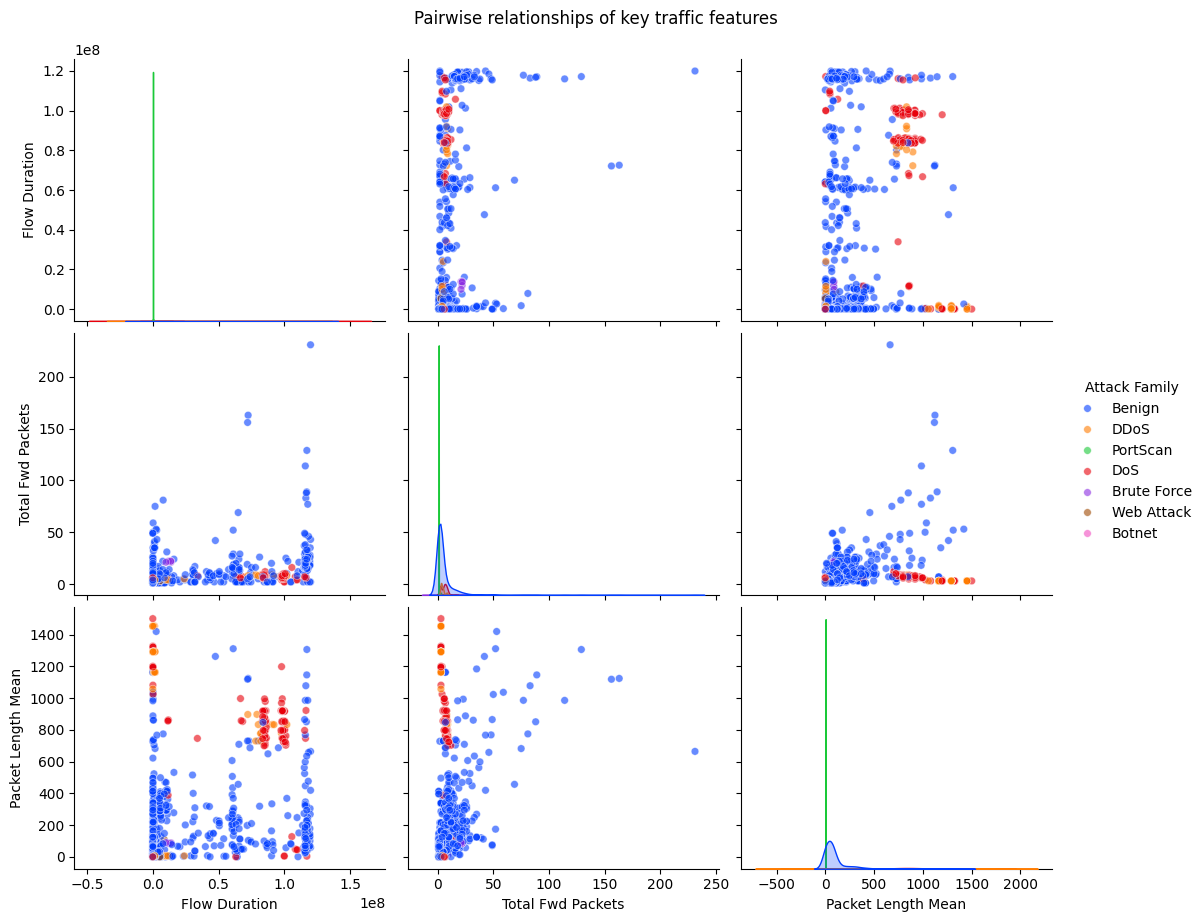

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


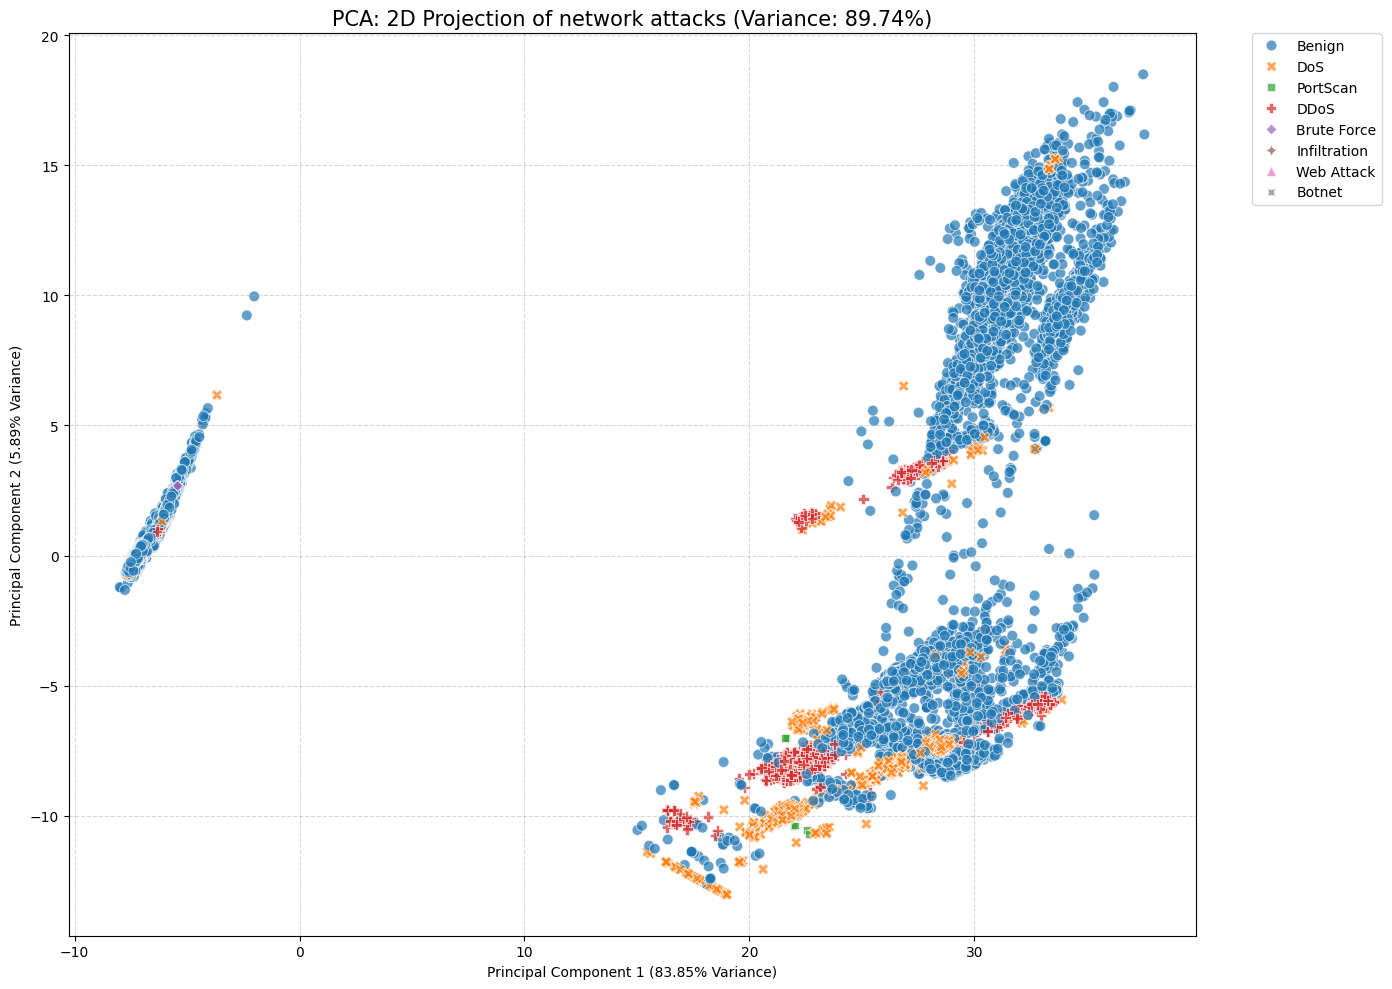

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
df_pca_sample, _ = train_test_split(df_clean, train_size=50000,
                                    stratify=df_clean['Attack Family'],
                                    random_state=42)

df_pair_sample, _ = train_test_split(df_clean, train_size=2000,
                                        stratify=df_clean['Attack Family'],
                                        random_state=42)

features_to_plot = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean']
pair_data = df_pair_sample[features_to_plot + ['Attack Family']].copy()

g = sns.pairplot(pair_data, hue='Attack Family', palette='bright',
                    height=3, aspect=1.2, plot_kws={'alpha': 0.6, 's': 30})

g.figure.suptitle('Pairwise relationships of key traffic features', y=1.02)
plt.show()

X = df_pca_sample.select_dtypes(include=[np.number])
X = X.drop(columns=['Destination Port'], errors='ignore')
y = df_pca_sample['Attack Family']

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_log = np.log1p(X)
X_log = X_log.replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Attack Family'] = y.reset_index(drop=True)

plt.figure(figsize=(14, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Attack Family', data=pca_df,
                alpha=0.7, palette='tab10', style='Attack Family', s=60)

plt.title(f'PCA: 2D Projection of network attacks (Variance: {sum(pca.explained_variance_ratio_):.2%})', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation:**
1. Pairwise relationships: PortScan (Green) is highly distinct. DoS/DDoS (Red/Orange) tend to have very high durations but relatively low packet counts. Benign (Blue) traffic is scattered everywhere.
2. PCA: The data is split into two clusters separated by a large gap. Left cluster is mostly Benign traffic with some Brute Force and DoS mixed in. Right cluster is a high-variance group containing massive Benign flows mixed with DDoS and DoS attacks. Dos and DDos attacks form distinct, straight horizontal bands or tight clusters on the right side. Benign traffic appears everywhere. Since PC1 explains 83.85% of the variance and separates the two main groups this is the single most important difference between these network flows.

Attack families are separable partially, some are easy to classify and some are very hard, and there is also the issue with the Benign traffic which overlaps pretty much all traffic data.

## 3. Feature Engineering

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neighbors import KNeighborsClassifier

df_clean = df.replace([np.inf, -np.inf], np.nan)
df_clean.dropna(inplace=True)

X = df_clean.drop(columns=['Label', 'Attack Family'])
y = df_clean['Attack Family']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_subset, _, y_subset, _ = train_test_split(X_train_scaled, y_train, train_size=10000, stratify=y_train, random_state=42)
class_counts = y_subset.value_counts()
valid_classes = class_counts[class_counts >= 3].index
X_subset = X_subset.reset_index(drop=True)
y_subset = y_subset.reset_index(drop=True)
mask = y_subset.isin(valid_classes)
X_subset = X_subset[mask]
y_subset = y_subset[mask]

knn = KNeighborsClassifier(n_neighbors=3)

sfs = SequentialFeatureSelector(knn, n_features_to_select=30, direction='forward', cv=3)
sfs.fit(X_subset, y_subset)
selected_forward = X.columns[sfs.get_support()].tolist()
print(f"\nForward selection (Top 30): {selected_forward}")

sbs = SequentialFeatureSelector(knn, n_features_to_select=30, direction='backward', cv=3)
sbs.fit(X_subset, y_subset)
selected_backward = X.columns[sbs.get_support()].tolist()
print(f"\nBackward selection (Top 30): {selected_backward}")

sbis = SFS(knn, k_features=30, forward=True, floating=True, scoring='accuracy', cv=3, n_jobs=-1)
sbis.fit(X_subset, y_subset)
selected_bidirectional = list(sbis.k_feature_names_)
print(f"\nBidirectional (Top 30): {selected_bidirectional}")


Forward selection (Top 30): ['Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Flow IAT Min', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Packet Length Std', 'FIN Flag Count', 'RST Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Max']

Backward selection (Top 30): ['Flow Duration', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd PSH Flags', 'Min Packet Le

In [3]:
from collections import Counter

all_votes = selected_forward + selected_backward + selected_bidirectional
counts = Counter(all_votes)

final_features = [feat for feat, count in counts.items() if count >= 2]

print(f"Total combined features: {len(set(all_votes))}")
print(f"Selected features: {len(final_features)}")
print("Final feature set:")
print(final_features)

X_train_seq = X_train[final_features]
X_test_seq = X_test[final_features]

Total combined features: 57
Selected features: 28
Final feature set:
['Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'FIN Flag Count', 'RST Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Fwd IAT Min', 'ACK Flag Count']


Strategy A: I employed three different sequential selection methods to identify predictive features. To avoid the biases of a single algorithm, I adopted a majority consensus rule, selecting only features that appeared in at least two of the three methods. This helped reduce the feature set from 79 to 28.

Original features: 78
PCA components retained: 25
Explained variance ratio: 0.9540


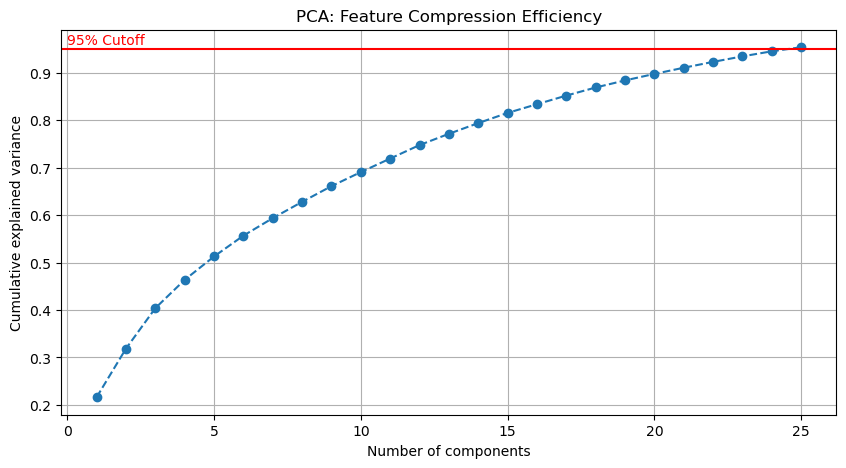

In [21]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = pca.n_components_
print(f"Original features: {X_train.shape[1]}")
print(f"PCA components retained: {n_components}")
print(f"Explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 5))

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = len(cumulative_variance)
x_axis = range(1, n_components + 1)
plt.plot(x_axis, cumulative_variance, marker='o', linestyle='--')

plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Feature Compression Efficiency')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0, 0.96, '95% Cutoff', color='red')
plt.show()

Strategy B: I performed Principal Component Analysis (PCA) on the full scaled dataset. The cumulative variance plot indicated that 25 Principal Components are sufficient to explain 95% of the total variance in the data.

To make sure how well each classifier performs I will be using both feature sets and comparing the results.

## 4. Multi-Class Classification Models

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "k-NN": KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
}

def training_loop(models, X_train_use, X_test_use, y_train_use, y_test_use):
   results = []
   for name, model in models.items():
      print(f"\nTraining {name}...")
      model.fit(X_train_use, y_train_use)
      y_pred = model.predict(X_test_use)

      target_names = model.classes_
      
      acc = accuracy_score(y_test_use, y_pred)
      f1 = f1_score(y_test_use, y_pred, average='macro')
      recalls = recall_score(y_test_use, y_pred, average=None, labels=target_names, zero_division=0)
      
      results.append({
         "Model": name,
         "Accuracy": acc,
         "Macro F1": f1,
         target_names[0] + " Recall": recalls[0],
         target_names[1] + " Recall": recalls[1],
         target_names[2] + " Recall": recalls[2],
         target_names[3] + " Recall": recalls[3],
         target_names[4] + " Recall": recalls[4],
         target_names[5] + " Recall": recalls[5],
         target_names[6] + " Recall": recalls[6],
         target_names[7] + " Recall": recalls[7]
      })


   return results

In [11]:
results = training_loop(models, X_train_seq, X_test_seq, y_train, y_test)
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.highlight_max(color='green', axis=0))


Training Decision Tree...

Training Naive Bayes...

Training k-NN...


,Accuracy,Macro F1,Benign Recall,Botnet Recall,Brute Force Recall,DDoS Recall,DoS Recall,Infiltration Recall,PortScan Recall,Web Attack Recall
Model,,,,,,,,,,
Decision Tree,0.998605,0.955389,0.998829,0.836317,0.996746,0.999805,0.997140,0.857143,0.999528,0.956422
Naive Bayes,0.046432,0.074273,0.009433,0.030691,0.996746,0.633431,0.051604,0.428571,0.000063,0.883028
k-NN,0.998108,0.952079,0.998457,0.828645,0.994939,0.999219,0.995432,0.714286,0.999465,0.956422


- Decision Tree: Achieved the highest Macro F1 (0.955) and dominated in detecting rare attacks. At Infiltration Recall (0.857) it captured the hardest class almost perfectly.
- Naive Bayes: Failure to classify (Accuracy: 4.6%). The Benign Recall of 0.009. It classified almost all normal traffic as malicious (False Positives).
- k-NN: Excellent performance (Macro F1: 0.952), nearly matching the Decision Tree.

In [12]:
results = training_loop(models, X_train_pca, X_test_pca, y_train, y_test)
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.highlight_max(color='green', axis=0))


Training Decision Tree...

Training Naive Bayes...

Training k-NN...


,Accuracy,Macro F1,Benign Recall,Botnet Recall,Brute Force Recall,DDoS Recall,DoS Recall,Infiltration Recall,PortScan Recall,Web Attack Recall
Model,,,,,,,,,,
Decision Tree,0.998032,0.855192,0.998844,0.739130,0.993131,0.998633,0.997140,0.285714,0.991656,0.958716
Naive Bayes,0.238109,0.237726,0.087319,0.056266,0.707520,0.925054,0.763154,0.428571,0.961809,0.839450
k-NN,0.996683,0.900942,0.997184,0.672634,0.993492,0.998946,0.997855,0.571429,0.990901,0.944954


- Decision Tree: While accuracy remained high, Macro F1 dropped to 0.855. Crucially, Infiltration Recall collapsed to 0.285.
- Naive Bayes: Improved slightly (Accuracy: 23%), but still unusable.
- k-NN: It performed worse than on Strategy A, but it outperformed the Decision Tree on the PCA dataset (Macro F1: 0.9).

The Decision Tree trained on Selected Features (Strategy A) is the superior model.

## 5. Monte-Carlo Cross-Validation (MCCV)

In [15]:
from tqdm import tqdm

X_full = pd.concat([X_train_seq, X_test_seq], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

results_mccv = []
for i in tqdm(range(100), desc="MCCV Progress"):
    X_subset, _, y_subset, _ = train_test_split(X_full, y_full, train_size=0.0625, stratify=y_full, random_state=None)
    X_tr, X_te, y_tr, y_te = train_test_split(X_subset, y_subset, test_size=0.3, stratify=y_subset, random_state=None) 
    
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, average='macro')

        classes = list(model.classes_)
        recalls = recall_score(y_te, y_pred, average=None, labels=classes, zero_division=0)

        result_entry = {
            "Iteration": i,
            "Model": name,
            "Accuracy": acc,
            "Macro F1": f1
        }

        for cls_name, cls_recall in zip(classes, recalls):
            result_entry[f"{cls_name} Recall"] = cls_recall
            
        results_mccv.append(result_entry)


df_results = pd.DataFrame(results_mccv).fillna(0)

MCCV Progress: 100%|██████████| 100/100 [06:22<00:00,  3.82s/it]


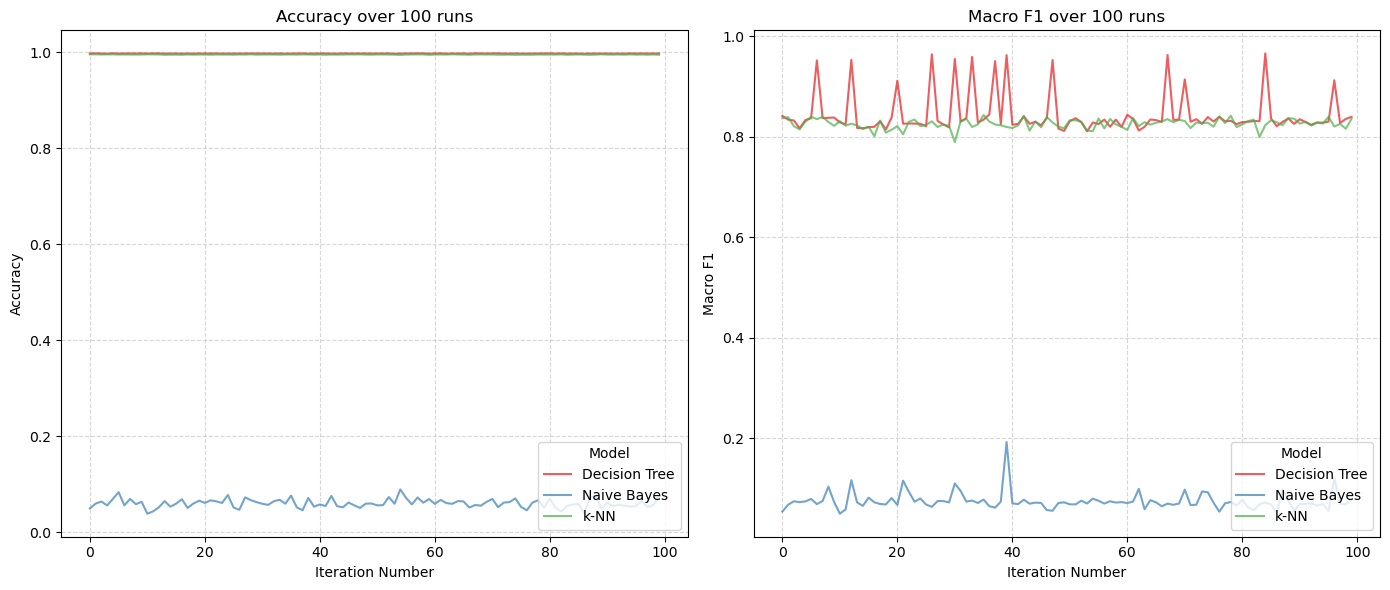


MCCV statistical summary:


Accuracy            Macro F1           Benign Recall            \
                   mean       std      mean       std          mean       std   
Model                                                                           
Decision Tree  0.997678  0.000205  0.844709  0.041212      0.998116  0.000214   
Naive Bayes    0.059849  0.009107  0.074647  0.017741      0.022313  0.009776   
k-NN           0.995543  0.000279  0.825970  0.009634      0.997020  0.000299   

              Botnet Recall           Brute Force Recall            \
                       mean       std               mean       std   
Model                                                                
Decision Tree      0.770541  0.065923           0.988880  0.006682   
Naive Bayes        0.051081  0.038967           0.978571  0.094971   
k-NN               0.731892  0.092489           0.986293  0.006707   

              DDoS Recall           DoS Recall           Infiltration Recall  \
                     mean       std       mean       std                mean   
Model                                                                          
Decision Tree    0.998817  0.000782   0.995227  0.001196                0.13   
Naive Bayes      0.634702  0.011811   0.086653  0.027698                0.18   
k-NN             0.995718  0.001450   0.984358  0.001915                0.00   

                        PortScan Recall           Web Attack Recall            
                    std            mean       std              mean       std  
Model                                                                          
Decision Tree  0.337998        0.999268  0.000576          0.924634  0.037991  
Naive Bayes    0.386123        0.000050  0.000146          0.842927  0.055825  
k-NN           0.000000        0.997676  0.001027          0.904146  0.053846

In [18]:
df_results = pd.DataFrame(results_mccv)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_results, x="Iteration", y="Accuracy", hue="Model", 
             palette="Set1", alpha=0.7, linewidth=1.5)
plt.title(f"Accuracy over 100 runs")
plt.ylabel("Accuracy")
plt.xlabel("Iteration Number")
plt.legend(title="Model", loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
sns.lineplot(data=df_results, x="Iteration", y="Macro F1", hue="Model", 
             palette="Set1", alpha=0.7, linewidth=1.5)
plt.title(f"Macro F1 over 100 runs")
plt.ylabel("Macro F1")
plt.xlabel("Iteration Number")
plt.legend(title="Model", loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

summary = df_results.groupby("Model")[["Accuracy", "Macro F1"] + [classes[i] + " Recall" for i in range(len(classes))]].agg(['mean', 'std'])
print("\nMCCV statistical summary:")
display(summary)

## 6. Hyperparameter Tuning

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(1, 20),
    'max_features': [None, 'sqrt', 'log2']
}

dt = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_seq, y_train)
print(f"Best Parameters Found: {random_search.best_params_}")

base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train_seq, y_train)
y_pred_base = base_model.predict(X_test_seq)

tuned_model = random_search.best_estimator_
tuned_model.fit(X_train_seq, y_train)
y_pred_tuned = tuned_model.predict(X_test_seq)


def get_metrics(model, y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    classes = list(model.classes_)
    recalls = recall_score(y_true, y_pred, average=None, labels=classes, zero_division=0)

    result = {
        "Model": name,
        "Accuracy": acc,
        "Macro F1": f1
    }

    for cls_name, cls_recall in zip(classes, recalls):
        result[f"{cls_name} Recall"] = cls_recall
        
    return result


results = [
    get_metrics(base_model, y_test, y_pred_base, "Base Decision Tree"),
    get_metrics(tuned_model, y_test, y_pred_tuned, "Tuned Decision Tree")
]

df_results = pd.DataFrame(results).set_index("Model")
print("\nBase model vs. Tuned model comparison:")
display(df_results.style.highlight_max(color='green', axis=0))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters Found: {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 9, 'splitter': 'best'}

Base model vs. Tuned model comparison:


,Accuracy,Macro F1,Benign Recall,Botnet Recall,Brute Force Recall,DDoS Recall,DoS Recall,Infiltration Recall,PortScan Recall,Web Attack Recall
Model,,,,,,,,,,
Base Decision Tree,0.998605,0.955389,0.998829,0.836317,0.996746,0.999805,0.997140,0.857143,0.999528,0.956422
Tuned Decision Tree,0.998746,0.953799,0.998884,0.767263,0.997108,0.999766,0.998709,0.857143,0.999559,0.961009
